In [1]:
# Weekend notebook on RL + SoRL
# ------------------------------
import gymnasium as gym
import metaworld
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

# --- Visualization Helper ---
def show_frames(frames, delay=0.05):
    """Simple player for notebook"""
    fig, ax = plt.subplots(figsize=(6, 4))
    img = ax.imshow(frames[0])
    ax.axis('off')
    
    for frame in frames:
        img.set_data(frame)
        display(fig)
        clear_output(wait=True)
        time.sleep(delay)


# Q2. how do I use a GAT on an environment? 
#  -- specifically, I'll need a sequence model (DiT) to handle the task
#  -- with our modification, it becomes DAT (decision abstraction transformer)
#  -- but we'd need to 'discretize' action space and state space, for SoRL requires joint prediction
# Q3. how do I build DAT here? 
# Q4. how do I discretize the state space? 
# -> A really simple way, is to just concatenate state & action, [s, a] and do joint prediction
# -> it actually doesn't matter if state is discrete or not, as long as we 'encode' it into latent
# -> and 'decode' it back to original space, for discrete action, we just need one-hot encoding

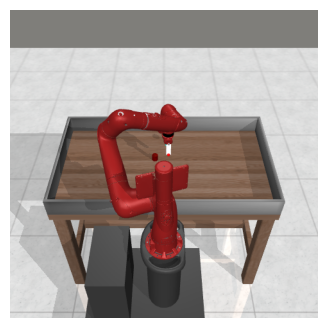

In [ ]:
# Using MetaWorld environment
ml1 = metaworld.ML1('reach-v3')
env = ml1.train_classes['reach-v3']()
env.set_task(ml1.train_tasks[0])
env.render_mode = 'rgb_array'

obs, acts = [], []
observation, info = env.reset()
frames = []

for _ in range(50):
    action = env.action_space.sample()
    obs.append(observation)
    acts.append(action)
    observation, reward, terminated, truncated, info = env.step(action)
    
    frame = env.render()
    frames.append(frame)

    if terminated or truncated:
        observation, info = env.reset()

env.close()

show_frames(frames)

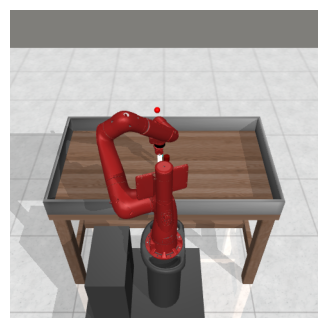

In [11]:
show_frames(frames)

In [ ]:
from dat.dat import DiT, DiTConfig

# MetaWorld has continuous action space, need to discretize for DiT
# Let's use 10 discrete action bins per dimension
action_bins = 10
discrete_action_dim = action_bins ** env.action_space.shape[0]

config = DiTConfig(
    state_dim=env.observation_space.shape[0],
    action_dim=discrete_action_dim,
    n_embd=256,
    n_head=4,
    device="cpu",
    _compile=False
)

dit = DiT(config)

In [ ]:
import numpy as np 
import torch

def discretize_action(action, bins=10):
    """Discretize continuous action to discrete bins"""
    # Normalize action from [-1, 1] to [0, bins-1]
    normalized = (action + 1.0) / 2.0  # [0, 1]
    discretized = (normalized * (bins - 1)).astype(int)
    discretized = np.clip(discretized, 0, bins - 1)
    
    # Convert multi-dimensional action to single index
    if len(discretized.shape) == 1:
        # Multi-dimensional action
        index = 0
        for i, val in enumerate(discretized):
            index = index * bins + val
        return index
    else:
        return discretized

# --- preprocess ---
obs = np.stack(obs, axis=0)
acts = np.stack(acts, axis=0)

# Discretize continuous actions
discrete_acts = np.array([discretize_action(action, action_bins) for action in acts])
acts_onehot = np.eye(discrete_action_dim)[discrete_acts] 
obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
acts_tensor = torch.tensor(acts_onehot, dtype=torch.float32).unsqueeze(0)

# -- forward pass --
pred_obs, pred_acts = dit._forward_pass(obs_tensor, acts_tensor)

# -- compute loss -- 
obs_loss, act_loss = dit(obs_tensor, acts_tensor)
# remark: when reward is provided, we use it to scale 'act_loss'

# -- take action --

In [26]:
acts_tensor.reshape(-1, action_dim).shape

torch.Size([10, 2])

In [20]:
pred_obs.shape

torch.Size([1, 10, 4])